## **Modelado Predictivo del Efecto Isla de Calor Urbano con Machine Learning**

**Cuál es la necesidad o problema a resolver? **
El efecto "Isla de Calor Urbano" (UHI, por sus siglas en inglés) es un fenómeno que ocurre en ciudades debido a la alta densidad de edificios y la falta de áreas verdes y cuerpos de agua. Esto genera variaciones de temperatura entre las zonas rurales y urbanas, afectando la calidad de vida, el consumo energético y la salud pública, especialmente en poblaciones vulnerables.
**¿Cuál es la propuesta para resolver esta necesidad? **
Desarrollar un modelo de Machine Learning que prediga las zonas con mayor intensidad del efecto isla de calor en un entorno urbano. Además, identificar los factores clave que contribuyen a la generación de estos puntos de calor, proporcionando información útil para la planificación urbana y la implementación de estrategias de mitigación.




In [12]:
# 📦 Librerías a instalar
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow

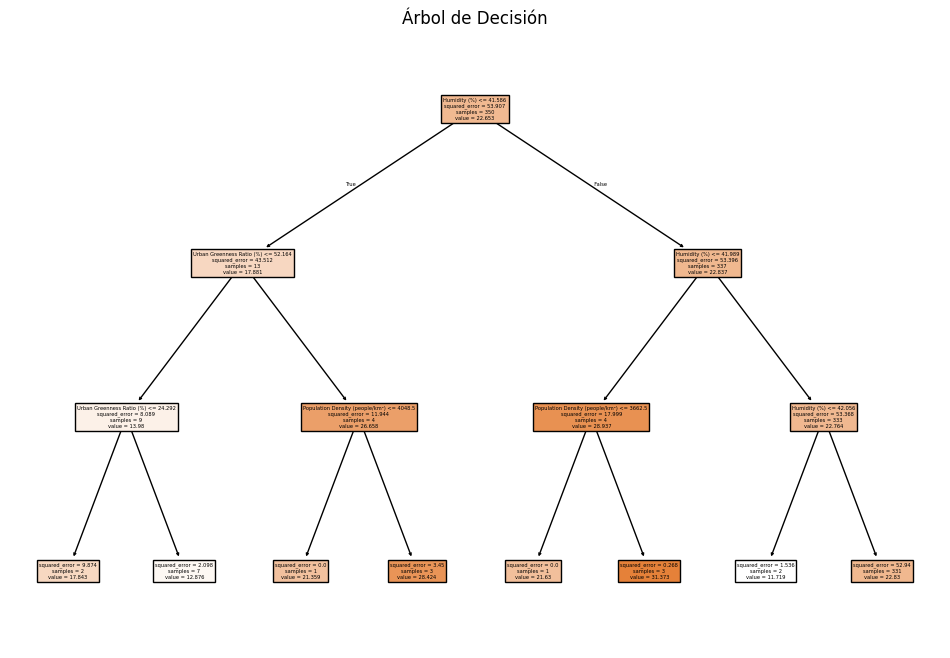

Predicciones Árbol de Decisión: [22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 12.87627187
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 12.87627187 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171 22.83033171
 22.83033171 22.830

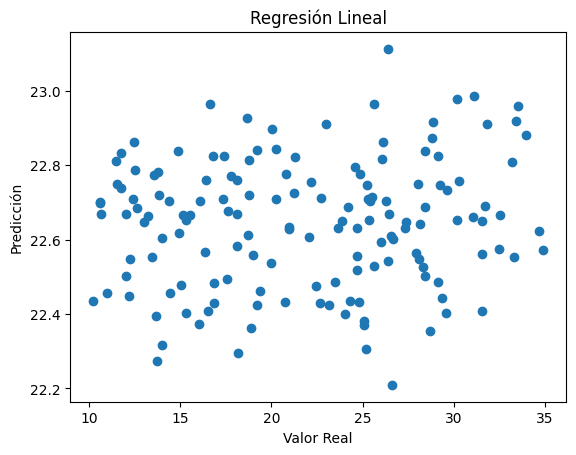

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 104.5372 
MSE Red Neuronal: 94.70634460449219


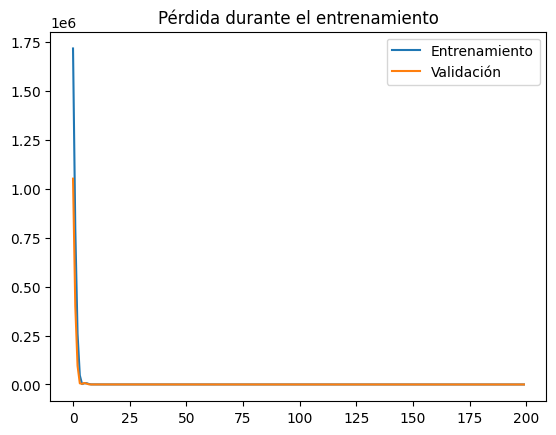

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


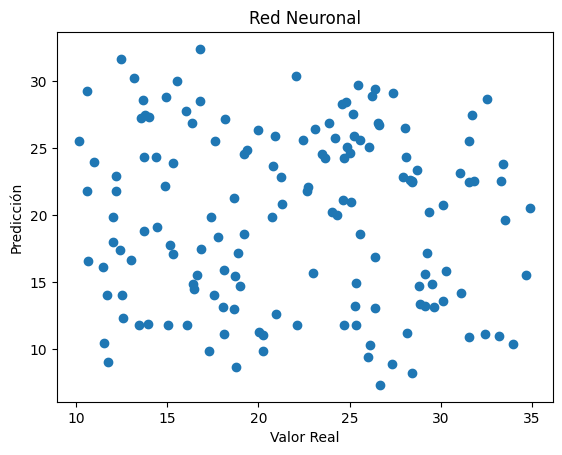

    City Name  cluster
0      City_1        2
1      City_2        1
2      City_3        0
3      City_4        1
4      City_5        1
..        ...      ...
495  City_496        1
496  City_497        0
497  City_498        2
498  City_499        1
499  City_500        1

[500 rows x 2 columns]


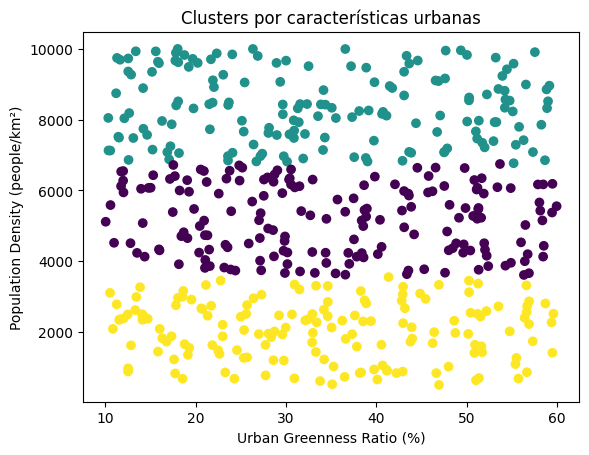

In [13]:


# 📌 Importar librerías
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Flatten
from sklearn.cluster import KMeans
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 📌 Cargar dataset desde CSV
data = pd.read_csv("/content/urban_heat_island_dataset.csv")

# 📌 Seleccionar variables relevantes
X = data[['Urban Greenness Ratio (%)', 'Population Density (people/km²)', 'Humidity (%)']]
y = data['Temperature (°C)']

# 📌 Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 📌 Árbol de decisión
model_tree = DecisionTreeRegressor(max_depth=3)
model_tree.fit(X_train, y_train)

plt.figure(figsize=(12,8))
tree.plot_tree(model_tree, feature_names=X.columns, filled=True)
plt.title("Árbol de Decisión")
plt.show()

predictions_tree = model_tree.predict(X_test)
print("Predicciones Árbol de Decisión:", predictions_tree)

# 📌 Regresión Lineal
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_lr = reg.predict(X_test)

print("MSE Regresión Lineal:", mean_squared_error(y_test, y_pred_lr))
print("R² Regresión Lineal:", r2_score(y_test, y_pred_lr))

plt.scatter(y_test, y_pred_lr)
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title('Regresión Lineal')
plt.show()

# 📌 Red Neuronal (MLP)
model_nn = Sequential()
model_nn.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
model_nn.add(Dense(8, activation='relu'))
model_nn.add(Dense(1, activation='linear'))

model_nn.compile(optimizer='adam', loss='mse')

history = model_nn.fit(X_train, y_train, epochs=200, verbose=0, validation_split=0.2)
loss_nn = model_nn.evaluate(X_test, y_test)
print("MSE Red Neuronal:", loss_nn)

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

y_pred_nn = model_nn.predict(X_test)
plt.scatter(y_test, y_pred_nn)
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title('Red Neuronal')
plt.show()

# 📌 Clustering K-means
kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(data[['Urban Greenness Ratio (%)', 'Population Density (people/km²)']])

print(data[['City Name', 'cluster']])

plt.scatter(data['Urban Greenness Ratio (%)'], data['Population Density (people/km²)'],
            c=data['cluster'], cmap='viridis')
plt.xlabel('Urban Greenness Ratio (%)')
plt.ylabel('Population Density (people/km²)')
plt.title('Clusters por características urbanas')
plt.show()



Index(['Date', 'Average Rainfall (mm)', 'Temperature Variability (C)',
       'Flood Incidence (count)', 'Airborne Particulate Matter (µg/m³)',
       'Healthcare Access Index', 'Disease Incidence Rate (%)'],
      dtype='object')
X_seq shape: (100, 100, 5), y_seq shape: (100, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - loss: 0.6517 - val_loss: 0.4083
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.4022 - val_loss: 0.2444
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2562 - val_loss: 0.1453
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1588 - val_loss: 0.1018
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1066 - val_loss: 0.1004
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1011 - val_loss: 0.1179
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1192 - val_loss: 0.1307
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1242 - val_loss: 0.1292
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1177 - val_loss: 0.1182
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1107 - val_loss: 0.1061
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1042 - val_loss: 0.0987
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0984 - val_loss: 0.0958
Epoch 13/50

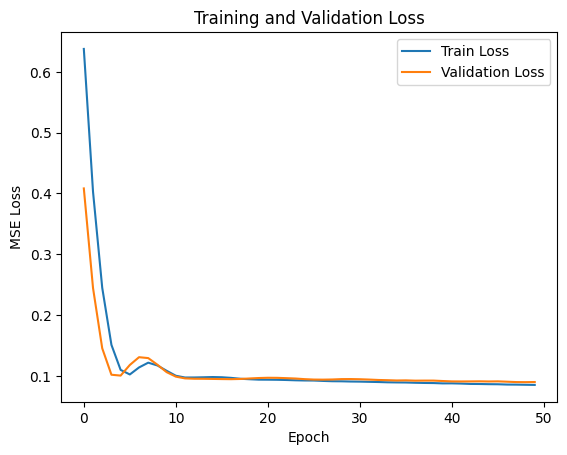

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from google.colab import files  # Import files for uploading

# 📥 Upload the dataset (if needed)
# This will prompt you to select the file from your local machine
try:
    series_data = pd.read_csv('/content/Disease_Incidence_Rate.csv')
except FileNotFoundError:
    print("File 'Disease_Incidence_Rate.csv' not found in '/content/'. Uploading...")
    uploaded = files.upload()
    # Assuming you uploaded 'Disease_Incidence_Rate.csv'
    series_data = pd.read_csv('Disease_Incidence_Rate.csv')

# 📊 Ver columnas para confirmar nombres correctos
print(series_data.columns)

# 📌 Seleccionar variables relevantes (features y target)
# Check the actual column name in the DataFrame and correct any typos
# Remove special character 'Â' if present in the column name
features = ['Average Rainfall (mm)', 'Temperature Variability (C)', 'Flood Incidence (count)',
            'Airborne Particulate Matter (µg/m³)', 'Healthcare Access Index']
target = 'Disease Incidence Rate (%)'

# 📏 Escalar datos
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(series_data[features])
scaled_target = scaler.fit_transform(series_data[[target]])

# 📦 Crear secuencias para series temporales
def create_sequences(features_data, target_data, seq_length):
    X, y = [], []
    for i in range(len(features_data) - seq_length):
        X.append(features_data[i:i + seq_length])
        y.append(target_data[i + seq_length])
    return np.array(X), np.array(y)

# 📌 Definir longitud de secuencia (por ejemplo 10)
seq_length = 100
X_seq, y_seq = create_sequences(scaled_features, scaled_target, seq_length)

# 📐 Mostrar forma de los datos
print(f'X_seq shape: {X_seq.shape}, y_seq shape: {y_seq.shape}')

# 🧠 Definir modelo GRU
model_gru = Sequential()
model_gru.add(GRU(50, input_shape=(X_seq.shape[1], X_seq.shape[2])))
model_gru.add(Dense(1))  # salida escalar

# ⚙️ Compilar modelo
model_gru.compile(optimizer='adam', loss='mse')

# 🏋️‍♂️ Entrenar modelo
history_gru = model_gru.fit(
    X_seq, y_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 📉 Graficar pérdidas
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [17]:
# 📌 CNN (requiere carpeta 'dataset/' con subcarpetas por clase)


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import os

# ============================
# 📥 CARGA Y PREPROCESAMIENTO
# ============================

# 1. Cargar datos tabulares
df = pd.read_csv('/content/Disease_Incidence_Rate.csv')

# 🔗 Creating a 'filename' column with dummy data if it doesn't exist.
# Replace this with your actual filename generation logic.
if 'filename' not in df.columns:
    df['filename'] = df.index.astype(str) + '.jpg'  # Replace with your logic if needed.

# 🔗 Asegúrate de que tienes una columna 'filename' que coincida con los nombres de imágenes
# Ejemplo de nombre de archivo en el CSV: 'class1/img123.jpg'
df['filename'] = df['filename'].astype(str)

# 2. Preparar datos tabulares
tabular_features = ['Average Rainfall (mm)', 'Temperature Variability (C)', 'Flood Incidence (count)',
                    'Airborne Particulate Matter (µg/m³)', 'Healthcare Access Index']
target = 'Disease Incidence Rate (%)'

scaler = MinMaxScaler()
scaled_tabular = scaler.fit_transform(df[tabular_features])
scaled_target = df[[target]].values

# 3. Preparar datos de imagen
img_datagen = ImageDataGenerator(rescale=1./255)

# **Change 1: Print loaded filenames for debugging**
image_generator = img_datagen.flow_from_directory(
    '/content/UH/',  # **Change 2: Verify this path**
    target_size=(150, 150),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

print("Loaded Filenames:", image_generator.filenames) # Check which files are loaded.

# Obtener lista de archivos cargados por el generador
loaded_filenames = image_generator.filenames

# 4. Asegurar que el orden coincida
# Filtrar el DataFrame para que tenga el mismo orden que image_generator
# **Change 3: Handle case where no filenames are loaded.**
if len(loaded_filenames) > 0:
    df_sorted = df.set_index('filename').loc[loaded_filenames].reset_index()
else:
    print("WARNING: No image files loaded. Check your image directory and filenames.")
    df_sorted = pd.DataFrame(columns=df.columns) # Create empty DataFrame

# ============================
# 🧠 MODELO CNN (VGG16) PARA EXTRAER FEATURES DE IMAGEN
# ============================

vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
for layer in vgg.layers:
    layer.trainable = False

flat = Flatten()(vgg.output)
cnn_model = Model(inputs=vgg.input, outputs=flat)

# Extraer features desde VGG16
# **Change 4: Only predict if image_generator has data**
if len(image_generator.filenames) > 0:
    image_features = cnn_model.predict(image_generator, verbose=1)
else:
    print("WARNING: Skipping image feature extraction because no images were loaded.")
    image_features = np.array([]) # Empty array

# ============================
# 🔗 COMBINAR IMAGEN + DATOS
# ============================

# **Change 5: Handle case where no image features are extracted**
if image_features.size > 0:
    combined_input = np.concatenate([image_features, scaled_tabular], axis=1)
else:
    print("WARNING: Using only tabular data because no image features were extracted.")
    combined_input = scaled_tabular

# ============================
# 🔮 MODELO FINAL (DENSO)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import os

# ============================
# 📥 CARGA Y PREPROCESAMIENTO
# ============================

# 1. Cargar datos tabulares
df = pd.read_csv('/content/Disease_Incidence_Rate.csv')

# 🔗 Creating a 'filename' column with dummy data if it doesn't exist.
# Replace this with your actual filename generation logic.
if 'filename' not in df.columns:
    df['filename'] = df.index.astype(str) + '.jpg'  # Replace with your logic if needed.

# 🔗 Asegúrate de que tienes una columna 'filename' que coincida con los nombres de imágenes
# Ejemplo de nombre de archivo en el CSV: 'class1/img123.jpg'
df['filename'] = df['filename'].astype(str)

# 2. Preparar datos tabulares
tabular_features = ['Average Rainfall (mm)', 'Temperature Variability (C)', 'Flood Incidence (count)',
                    'Airborne Particulate Matter (µg/m³)', 'Healthcare Access Index']
target = 'Disease Incidence Rate (%)'

scaler = MinMaxScaler()
scaled_tabular = scaler.fit_transform(df[tabular_features])
scaled_target = df[[target]].values

# 3. Preparar datos de imagen
img_datagen = ImageDataGenerator(rescale=1./255)

# **Change 1: Print loaded filenames for debugging**
image_generator = img_datagen.flow_from_directory(
    '/content/UH/',  # **Change 2: Verify this path**
    target_size=(150, 150),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

print("Loaded Filenames:", image_generator.filenames) # Check which files are loaded.

# Obtener lista de archivos cargados por el generador
loaded_filenames = image_generator.filenames

# 4. Asegurar que el orden coincida
# Filtrar el DataFrame para que tenga el mismo orden que image_generator
# **Change 3: Handle case where no filenames are loaded.**
if len(loaded_filenames) > 0:
    df_sorted = df.set_index('filename').loc[loaded_filenames].reset_index()
else:
    print("WARNING: No image files loaded. Check your image directory and filenames.")
    df_sorted = pd.DataFrame(columns=df.columns) # Create empty DataFrame

# ============================
# 🧠 MODELO CNN (VGG16) PARA EXTRAER FEATURES DE IMAGEN
# ============================

vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
for layer in vgg.layers:
    layer.trainable = False

flat = Flatten()(vgg.output)
cnn_model = Model(inputs=vgg.input, outputs=flat)

# Extraer features desde VGG16
# **Change 4: Only predict if image_generator has data**
if len(image_generator.filenames) > 0:
    image_features = cnn_model.predict(image_generator, verbose=1)
else:
    print("WARNING: Skipping image feature extraction because no images were loaded.")
    image_features = np.array([]) # Empty array

# ============================
# 🔗 COMBINAR IMAGEN + DATOS
# ============================

# **Change 5: Handle case where no image features are extracted**
if image_features.size > 0:
    combined_input = np.concatenate([image_features, scaled_tabular], axis=1)
else:
    print("WARNING: Using only tabular data because no image features were extracted.")
    combined_input = scaled_tabular

# ============================
# 🔮 MODELO FINAL (DENSO)
# ============================

final_model = Sequential()
final_model.add(Dense(256, activation='relu', input_shape=(combined_input.shape[1],)))
final_model.add(Dense(128, activation='relu'))
final_model.add(Dense(1)) # Output layer for regression

Found 0 images belonging to 0 classes.
Loaded Filenames: []
Found 0 images belonging to 0 classes.
Loaded Filenames: []


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
